# Validation of kinGEMs iML1515 Models

This notebook uses the validation utility functions to analyze kinGEMs-produced iML1515 models and compare them with experimental data.

## 1. Load Required Libraries and Functions

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import cobra
import matplotlib.pyplot as plt

# Add parent directory to path to import kinGEMs
sys.path.append(os.path.abspath('..'))

from kinGEMs.validation_utils import (
    prepare_model,
    load_environment,
    load_data,
    match_model_data,
    model_adjustments,
    check_environment,
    test_growth,
    simulate_phenotype,
    simulate_phenotype_flux,
    calculate_phenotypes_with_dataframe
)

from kinGEMs.config import ECOLI_VALIDATION_DIR, MODELS_DIR

# Silence warnings
import warnings
warnings.filterwarnings('ignore')

c:\Users\lyachinas\miniconda3\envs\kingems\Lib\site-packages\bioservices\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-10-16 11:33:08.860 | INFO     | kinGEMs.config:<module>:12 - PROJ_ROOT path is: C:\Users\lyachinas\OneDrive - University of Toronto\GitHub\kinGEMs_v2


## 2. Import Model and Experimental Data

Load your kinGEMs-produced model and the experimental growth data.

In [2]:
# Load the genome-scale model
model_path = os.path.join(MODELS_DIR, 'ecoli_iML1515_20250826_4941.xml')
model = cobra.io.read_sbml_model(model_path)

print("Genes in saved model:", len(model.genes))

# Load experimental data from ECOLI_VALIDATION_DIR
data_dir = ECOLI_VALIDATION_DIR

# Load experimental validation data (Keio fitness)
keio_fitness_path = os.path.join(data_dir, 'fit_organism_Keio.tsv')
keio_fitness_data = pd.read_table(keio_fitness_path)

Genes in saved model: 1516


In [3]:
# Diagnostic: Print gene and reaction counts after model load
print("[Step] After loading model:")
print("  Genes in model:", len(model.genes))
print("  Reactions in model:", len(model.reactions))
model_gene_ids = set([g.id for g in model.genes])
model_rxn_ids = set([r.id for r in model.reactions])
print("  First 10 gene IDs:", list(model_gene_ids)[:10])
print("  First 10 reaction IDs:", list(model_rxn_ids)[:10])

# Diagnostic: Print kcat coverage if available
rxn_with_kcat = []
rxn_without_kcat = []
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        rxn_with_kcat.append(rxn.id)
    else:
        rxn_without_kcat.append(rxn.id)
print(f"  Reactions with kcat: {len(rxn_with_kcat)}")
print(f"  Reactions without kcat: {len(rxn_without_kcat)}")

[Step] After loading model:
  Genes in model: 1516
  Reactions in model: 2712
  First 10 gene IDs: ['b2293', 'b0207', 'b2965', 'b2156', 'b3925', 'b1746', 'b0087', 'b0383', 'b1740', 'b1385']
  First 10 reaction IDs: ['EX_met__D_e', 'NTPP11', 'TKT2', 'CTECOAI7', 'GGGABAH', '3OAR80', 'ACSERtpp', 'CHTBSptspp', 'ILEtex', 'ADCS']
  Reactions with kcat: 2136
  Reactions without kcat: 576


## 3. Apply Validation Functions

Match model components with experimental data and perform initial validations.

In [4]:
# 1. Prepare model (set exchange bounds)
model = prepare_model(model)

# 2. Load environment (medium and carbon sources)
name_medium_model, name_carbon_model, name_carbon_experiment = load_environment(ECOLI_VALIDATION_DIR)

# 3. Load experimental data
data_experiments, data_genes, data_fitness = load_data(ECOLI_VALIDATION_DIR)

# 4. Match model and data
name_genes_matched, name_carbon_experiment_matched, name_carbon_model_matched, data_fitness_matched = match_model_data(
    model=model,
    name_carbon_model=name_carbon_model,
    name_carbon_experiment=name_carbon_experiment,
    data_experiments=data_experiments,
    data_genes=data_genes,
    data_fitness=data_fitness
)

# 5. Adjust model and matched data
model_adj, name_genes_matched_adj, name_carbon_experiment_matched_adj, name_carbon_model_matched_adj, data_fitness_matched_adj = model_adjustments(
    adj_strain=True,
    adj_essential=True,
    adj_carbon=True,
    model=model,
    name_genes_matched=name_genes_matched,
    name_carbon_experiment_matched=name_carbon_experiment_matched,
    name_carbon_model_matched=name_carbon_model_matched,
    data_fitness_matched=data_fitness_matched
)

# 6. Check environment setup
medium_ex_inds, carbon_ex_inds = check_environment(
    model_adj=model_adj,
    name_medium_model=name_medium_model,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj
)

Matching model genes to data genes...
Matched 1339 genes.
Matching experimental carbon sources to model carbon sources...
Matched 54 carbon sources.
Shape of matched fitness data: (1339, 54)
Averaging fitness data for replicate carbon sources...
Final shape of averaged fitness data: (1339, 27)
Unique carbon sources after averaging: 27
Removing strain genes:
['b0066' 'b0348' 'b3909']
Removing essential genes: 
Removing carbon sources: 
['man' 'sucr']


## 4. Test Growth Predictions

Analyze model growth predictions and compare with experimental data.

In [ ]:
# 6. Test growth and simulate phenotypes
growth_results = test_growth(
    model_adj=model_adj,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj,
    medium_ex_inds=medium_ex_inds,
    carbon_ex_inds=carbon_ex_inds
)

processed_df = pd.read_csv('./results/tuning_results/ecoli_iML1515_20250826_4941/df_new.csv')
objective_reaction = 'BIOMASS_Ec_iML1515_core_75p37M'
enzyme_upper_bound = 0.15

data_fitness_simulated_baseline, data_fitness_simulated_ecGEM = simulate_phenotype(
    model_run=model_adj,
    name_genes_matched_adj=name_genes_matched_adj,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj,
    medium_ex_inds=medium_ex_inds,
    carbon_ex_inds=carbon_ex_inds,
    processed_df=processed_df,
    objective_reaction=objective_reaction,
    enzyme_upper_bound=enzyme_upper_bound
)

Growth with no carbon source (base medium only): Growth (Objective value: 0.142058163434682)

Testing growth on 25 carbon sources...


Testing carbon sources:  24%|██▍       | 6/25 [00:00<00:00, 56.96carbon/s]

  Growth with carbon source 'ac': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'acgam': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'akg': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'fru': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'fuc__L': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'g6p': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'gal': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'galur': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'gam': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'glc__D': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'glcn': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'glcur': Growth (Solution: 0.157842403816313)


Testing carbon sources:  52%|█████▏    | 13/25 [00:00<00:00, 59.85carbon/s]

  Growth with carbon source 'glyc': Growth (Solution: 0.157842403816313)


...

Testing carbon sources:  76%|███████▌  | 19/25 [00:00<00:00, 41.16carbon/s]

  Growth with carbon source 'pyr': Growth (Solution: 0.157842403816313)


Testing carbon sources: 100%|██████████| 25/25 [00:00<00:00, 47.73carbon/s]


  Growth with carbon source 'rib__D': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'sbt__D': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'ser__D': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'succ': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'tre': Growth (Solution: 0.157842403816313)
  Growth with carbon source 'xyl__D': Growth (Solution: 0.157842403816313)

Baseline GEM Simulation
Total simulations: 1336 genes × 25 carbon sources = 33400 optimizations


Baseline GEM:   3%|▎         | 957/33400 [00:05<02:48, 192.98simulation/s, carbon=ac, gene=951/1336]

In [ ]:
data_fitness_simulated_baseline, data_fitness_simulated_ecGEM = data_fitness_simulated 

## 5. Analyze Model Performance

Calculate performance metrics and visualize results.

Baseline GEM Model Performance Metrics:
  Accuracy: 0.472
  Precision: 0.437
  Recall: 0.996
  F1 Score: 0.608
ecGEM Model Performance Metrics:
  Accuracy: 0.477
  Precision: 0.437
  Recall: 0.956
  F1 Score: 0.600


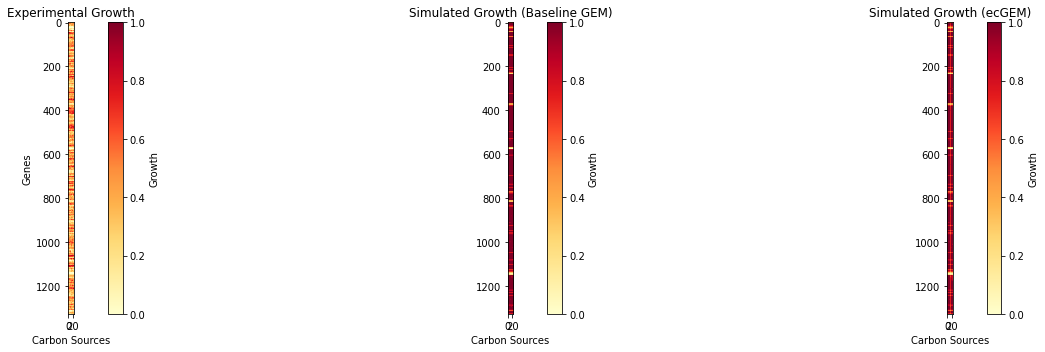

In [ ]:
# Create binary growth matrices (threshold at 0.001) for both baseline_GEM and ecGEM
thresh = 0.001
exp_binary = (data_fitness_matched_adj > 0).astype(float)  # Use matched/adjusted experimental data
sim_binary_baseline = (data_fitness_simulated_baseline > thresh).astype(float)
sim_binary_ecGEM = (data_fitness_simulated_ecGEM > thresh).astype(float)

def print_metrics(exp_binary, sim_binary, label):
    true_pos = np.sum((exp_binary == 1) & (sim_binary == 1))
    true_neg = np.sum((exp_binary == 0) & (sim_binary == 0))
    false_pos = np.sum((exp_binary == 0) & (sim_binary == 1))
    false_neg = np.sum((exp_binary == 1) & (sim_binary == 0))
    accuracy = (true_pos + true_neg) / np.prod(exp_binary.shape)
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print(f'{label} Model Performance Metrics:')
    print(f'  Accuracy: {accuracy:.3f}')
    print(f'  Precision: {precision:.3f}')
    print(f'  Recall: {recall:.3f}')
    print(f'  F1 Score: {f1_score:.3f}')

# Print metrics for both models
print_metrics(exp_binary, sim_binary_baseline, 'Baseline GEM')
print_metrics(exp_binary, sim_binary_ecGEM, 'ecGEM')

# Plot comparison heatmaps for both models
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

im0 = axes[0].imshow(exp_binary, cmap='YlOrRd')
axes[0].set_title('Experimental Growth')
axes[0].set_xlabel('Carbon Sources')
axes[0].set_ylabel('Genes')

im1 = axes[1].imshow(sim_binary_baseline, cmap='YlOrRd')
axes[1].set_title('Simulated Growth (Baseline GEM)')
axes[1].set_xlabel('Carbon Sources')

im2 = axes[2].imshow(sim_binary_ecGEM, cmap='YlOrRd')
axes[2].set_title('Simulated Growth (ecGEM)')
axes[2].set_xlabel('Carbon Sources')

plt.colorbar(im0, ax=axes[0], label='Growth')
plt.colorbar(im1, ax=axes[1], label='Growth')
plt.colorbar(im2, ax=axes[2], label='Growth')
plt.tight_layout()
plt.show()

In [ ]:
# Advanced metrics calculation: binarize, flatten, append, and compute AUC/BAC/ROC metrics for both baseline and ecGEM
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_recall_curve as pre_rec, auc as sk_auc

sim_thresh = 0.001
fit_thresh = -2

# Use data_fitness_simulated_baseline and data_fitness_simulated_ecGEM from previous cells
# Use data_fitness_matched_adj for experimental fitness

def calc_metrics(data_sim, data_fit, fit_thresh, sim_thresh):
    data_sim_b = (data_sim > sim_thresh).astype(int)
    data_fit_b = (data_fit > fit_thresh).astype(int)
    num_genes = np.array([data_fit_b.shape[0]])
    num_genes_add = num_genes - num_genes[0]
    AC_i = np.zeros(len(num_genes_add))
    AUC_i = np.zeros(len(num_genes_add))
    BAC_i = np.zeros(len(num_genes_add))
    ROC_AUC_i = np.zeros(len(num_genes_add))
    for i in range(len(num_genes_add)):
        data_fit_b_V = data_fit_b.flatten()
        data_sim_b_V = data_sim_b.flatten()
        data_fit_V = data_fit.flatten()
        data_fit_b_V = np.append(data_fit_b_V, np.ones(num_genes_add[i]*data_fit_b.shape[1]))
        data_sim_b_V = np.append(data_sim_b_V, np.ones(num_genes_add[i]*data_fit_b.shape[1]))
        data_fit_V = np.append(data_fit_V, np.zeros(num_genes_add[i]*data_fit_b.shape[1]))
        tn, fp, fn, tp = confusion_matrix(data_fit_b_V, data_sim_b_V, labels=[1,0]).ravel()
        AC_i[i] = (tp+tn)/(tn+fn+tp+fp)
        pre, rec, thresholds = pre_rec(data_sim_b_V, data_fit_V*-1, pos_label=0)
        AUC_i[i] = sk_auc(rec, pre)
        TPR = tp/(tp+fn) if (tp+fn) > 0 else 0
        TNR = tn/(tn+fp) if (tn+fp) > 0 else 0
        BAC_i[i] = (TPR+TNR)/2
        ROC_AUC_i[i] = roc_auc_score(data_sim_b_V, data_fit_V)
    return AC_i, AUC_i, BAC_i, ROC_AUC_i

# Baseline GEM metrics
AC_baseline, AUC_baseline, BAC_baseline, ROC_AUC_baseline = calc_metrics(data_fitness_simulated_baseline, data_fitness_matched_adj, fit_thresh, sim_thresh)
print('Baseline GEM:')
print('  Accuracy:', AC_baseline)
print('  AUC:', AUC_baseline)
print('  Balanced Accuracy:', BAC_baseline)
print('  ROC AUC:', ROC_AUC_baseline)

# ecGEM metrics
AC_ecGEM, AUC_ecGEM, BAC_ecGEM, ROC_AUC_ecGEM = calc_metrics(data_fitness_simulated_ecGEM, data_fitness_matched_adj, fit_thresh, sim_thresh)
print('ecGEM:')
print('  Accuracy:', AC_ecGEM)
print('  AUC:', AUC_ecGEM)
print('  Balanced Accuracy:', BAC_ecGEM)
print('  ROC AUC:', ROC_AUC_ecGEM)

Baseline GEM:
  Accuracy: [0.93843137]
  AUC: [0.61336852]
  Balanced Accuracy: [0.7509956]
  ROC AUC: [0.94069788]
ecGEM:
  Accuracy: [0.90467572]
  AUC: [0.47987821]
  Balanced Accuracy: [0.74272902]
  ROC AUC: [0.77857776]


In [24]:
# Print both baseline GEM and ecGEM metrics together for comparison
print('--- Model Metrics Comparison ---')
print('Baseline GEM:')
print('  Accuracy:', AC_baseline)
print('  AUC:', AUC_baseline)
print('  Balanced Accuracy:', BAC_baseline)
print('  ROC AUC:', ROC_AUC_baseline)
print('ecGEM:')
print('  Accuracy:', AC_ecGEM)
print('  AUC:', AUC_ecGEM)
print('  Balanced Accuracy:', BAC_ecGEM)
print('  ROC AUC:', ROC_AUC_ecGEM)

--- Model Metrics Comparison ---
Baseline GEM:
  Accuracy: [0.93843137]
  AUC: [0.61336852]
  Balanced Accuracy: [0.7509956]
  ROC AUC: [0.94069788]
ecGEM:
  Accuracy: [0.90467572]
  AUC: [0.47987821]
  Balanced Accuracy: [0.74272902]
  ROC AUC: [0.77857776]


In [25]:
# Metrics for essential genes only
# Define essential genes as those with experimental fitness below a threshold (e.g., no growth)
essential_gene_mask = np.min(data_fitness_matched_adj, axis=1) <= 0.001  # Adjust threshold as needed

# Filter matrices for essential genes only
fit_ess = data_fitness_matched_adj[essential_gene_mask, :]
sim_baseline_ess = data_fitness_simulated_baseline[essential_gene_mask, :]
sim_ecGEM_ess = data_fitness_simulated_ecGEM[essential_gene_mask, :]

# Calculate metrics for essential genes
AC_baseline_ess, AUC_baseline_ess, BAC_baseline_ess, ROC_AUC_baseline_ess = calc_metrics(sim_baseline_ess, fit_ess, fit_thresh, sim_thresh)
print('Baseline GEM (Essential Genes):')
print('  Accuracy:', AC_baseline_ess)
print('  AUC:', AUC_baseline_ess)
print('  Balanced Accuracy:', BAC_baseline_ess)
print('  ROC AUC:', ROC_AUC_baseline_ess)

AC_ecGEM_ess, AUC_ecGEM_ess, BAC_ecGEM_ess, ROC_AUC_ecGEM_ess = calc_metrics(sim_ecGEM_ess, fit_ess, fit_thresh, sim_thresh)
print('ecGEM (Essential Genes):')
print('  Accuracy:', AC_ecGEM_ess)
print('  AUC:', AUC_ecGEM_ess)
print('  Balanced Accuracy:', BAC_ecGEM_ess)
print('  ROC AUC:', ROC_AUC_ecGEM_ess)

Baseline GEM (Essential Genes):
  Accuracy: [0.93686002]
  AUC: [0.61338067]
  Balanced Accuracy: [0.75072319]
  ROC AUC: [0.93922151]
ecGEM (Essential Genes):
  Accuracy: [0.90335654]
  AUC: [0.48388794]
  Balanced Accuracy: [0.7425149]
  ROC AUC: [0.78108983]


In [26]:
# Analyze genes with kcat data incorporated into the model
genes_with_kcat = set()
for rxn in model.reactions:
    ann = rxn.annotation if hasattr(rxn, 'annotation') else {}
    if 'kcat' in ann and ann['kcat'] not in [None, '', 0, '0']:
        for gene in rxn.genes:
            genes_with_kcat.add(gene.id)
print(f"Number of genes with kcat data: {len(genes_with_kcat)}")
print("First 10 genes with kcat data:", list(genes_with_kcat)[:10])
print("Proportion of genes with kcat data:", len(genes_with_kcat)/len(model.genes))
# Optionally, compare performance metrics for genes with kcat data
kcat_gene_mask = np.array([g in genes_with_kcat for g in name_genes_matched_adj])
fit_kcat = data_fitness_matched_adj[kcat_gene_mask, :]
sim_baseline_kcat = data_fitness_simulated_baseline[kcat_gene_mask, :]
sim_ecGEM_kcat = data_fitness_simulated_ecGEM[kcat_gene_mask, :]
AC_baseline_kcat, AUC_baseline_kcat, BAC_baseline_kcat, ROC_AUC_baseline_kcat = calc_metrics(sim_baseline_kcat, fit_kcat, fit_thresh, sim_thresh)
print('Baseline GEM (Genes with kcat):')
print('  Accuracy:', AC_baseline_kcat)
print('  AUC:', AUC_baseline_kcat)
print('  Balanced Accuracy:', BAC_baseline_kcat)
print('  ROC AUC:', ROC_AUC_baseline_kcat)
AC_ecGEM_kcat, AUC_ecGEM_kcat, BAC_ecGEM_kcat, ROC_AUC_ecGEM_kcat = calc_metrics(sim_ecGEM_kcat, fit_kcat, fit_thresh, sim_thresh)
print('ecGEM (Genes with kcat):')
print('  Accuracy:', AC_ecGEM_kcat)
print('  AUC:', AUC_ecGEM_kcat)
print('  Balanced Accuracy:', BAC_ecGEM_kcat)
print('  ROC AUC:', ROC_AUC_ecGEM_kcat)

Number of genes with kcat data: 1495
First 10 genes with kcat data: ['b2687', 'b2010', 'b2037', 'b0010', 'b0367', 'b0592', 'b4515', 'b0822', 'b0914', 'b1380']
Proportion of genes with kcat data: 0.9861477572559367
Baseline GEM (Genes with kcat):
  Accuracy: [0.93797856]
  AUC: [0.61013478]
  Balanced Accuracy: [0.75025256]
  ROC AUC: [0.93989126]
ecGEM (Genes with kcat):
  Accuracy: [0.90422665]
  AUC: [0.47840566]
  Balanced Accuracy: [0.74196512]
  ROC AUC: [0.77850074]


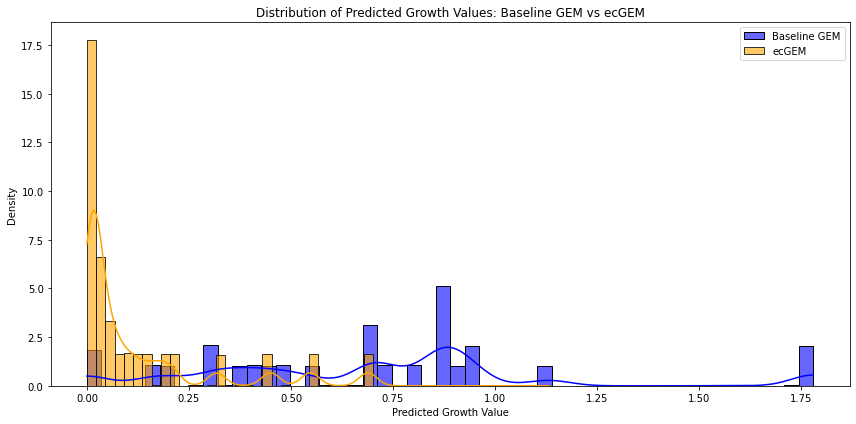

Summary statistics for Baseline GEM predictions:
count    3.315000e+04
mean     6.983937e-01
std      4.248717e-01
min     -3.510596e-12
25%      3.773558e-01
50%      7.046861e-01
75%      8.773090e-01
max      1.779800e+00
dtype: float64

Summary statistics for ecGEM predictions:
count    33150.000000
mean         0.119811
std          0.177055
min          0.000000
25%          0.014115
50%          0.030846
75%          0.153091
max          1.131312
dtype: float64


In [27]:
# Plot and print the distribution of predictions for baseline GEM and ecGEM
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
sns.histplot(data_fitness_simulated_baseline.flatten(), bins=50, color='blue', label='Baseline GEM', kde=True, stat='density', alpha=0.6)
sns.histplot(data_fitness_simulated_ecGEM.flatten(), bins=50, color='orange', label='ecGEM', kde=True, stat='density', alpha=0.6)
plt.xlabel('Predicted Growth Value')
plt.ylabel('Density')
plt.title('Distribution of Predicted Growth Values: Baseline GEM vs ecGEM')
plt.legend()
plt.tight_layout()
plt.show()
print('Summary statistics for Baseline GEM predictions:')
print(pd.Series(data_fitness_simulated_baseline.flatten()).describe())
print('\nSummary statistics for ecGEM predictions:')
print(pd.Series(data_fitness_simulated_ecGEM.flatten()).describe())

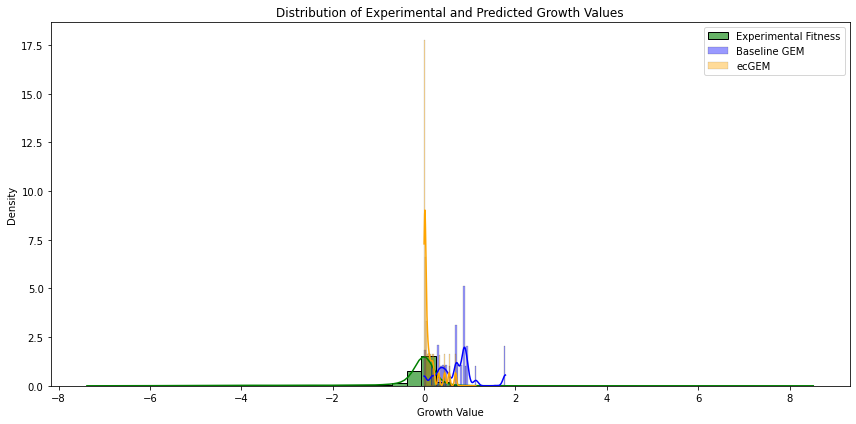

Summary statistics for Experimental Fitness values:
count    33150.000000
mean        -0.416262
std          1.188617
min         -7.381500
25%         -0.226500
50%         -0.037000
75%          0.072000
max          8.518500
dtype: float64


In [28]:
# Plot and print the distribution of actual experimental fitness values
plt.figure(figsize=(12,6))
sns.histplot(data_fitness_matched_adj.flatten(), bins=50, color='green', label='Experimental Fitness', kde=True, stat='density', alpha=0.6)
sns.histplot(data_fitness_simulated_baseline.flatten(), bins=50, color='blue', label='Baseline GEM', kde=True, stat='density', alpha=0.4)
sns.histplot(data_fitness_simulated_ecGEM.flatten(), bins=50, color='orange', label='ecGEM', kde=True, stat='density', alpha=0.4)
plt.xlabel('Growth Value')
plt.ylabel('Density')
plt.title('Distribution of Experimental and Predicted Growth Values')
plt.legend()
plt.tight_layout()
plt.show()
print('Summary statistics for Experimental Fitness values:')
print(pd.Series(data_fitness_matched_adj.flatten()).describe())

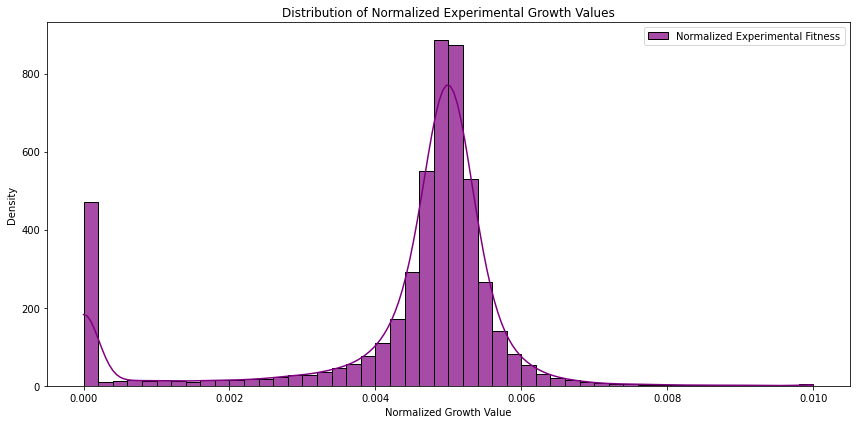

Summary statistics for Normalized Experimental Fitness values:
count    33150.000000
mean         0.004367
std          0.001665
min          0.000000
25%          0.004434
50%          0.004908
75%          0.005180
max          0.010000
dtype: float64


In [29]:
# Normalize experimental fitness data for growth alignment
def normalize_experimental_fitness(data, low_thresh=-2, high_thresh=2, min_growth=0, max_growth=0.01):
    norm_data = np.copy(data)
    norm_data[data <= low_thresh] = min_growth
    norm_data[data >= high_thresh] = max_growth
    # For values between thresholds, scale linearly between min_growth and max_growth
    mask = (data > low_thresh) & (data < high_thresh)
    norm_data[mask] = min_growth + (max_growth - min_growth) * (data[mask] - low_thresh) / (high_thresh - low_thresh)
    return norm_data
normalized_exp_fitness = normalize_experimental_fitness(data_fitness_matched_adj)
plt.figure(figsize=(12,6))
sns.histplot(normalized_exp_fitness.flatten(), bins=50, color='purple', label='Normalized Experimental Fitness', kde=True, stat='density', alpha=0.7)
plt.xlabel('Normalized Growth Value')
plt.ylabel('Density')
plt.title('Distribution of Normalized Experimental Growth Values')
plt.legend()
plt.tight_layout()
plt.show()
print('Summary statistics for Normalized Experimental Fitness values:')
print(pd.Series(normalized_exp_fitness.flatten()).describe())

## 6. Calculate Detailed Flux Phenotypes (Optional)

For more detailed analysis, calculate flux distributions for each condition.

In [ ]:
# Calculate Detailed Flux Phenotypes for Baseline GEM and ecGEM
print("Number of genes (matched/adj):", len(name_genes_matched_adj))
print("Number of carbon sources (matched/adj):", len(name_carbon_model_matched_adj))
print("Medium exchange indices:", medium_ex_inds)
print("Carbon exchange indices:", carbon_ex_inds)
print("First 5 gene IDs:", name_genes_matched_adj[:5])
print("First 5 carbon sources:", name_carbon_model_matched_adj[:5])

# Calculate flux phenotypes for both baseline and enzyme-constrained GEMs (this may take some time)
baseline_flux, enzyme_constrained_flux = simulate_phenotype_flux(
    model_run=model_adj,
    name_genes_matched_adj=name_genes_matched_adj,
    name_carbon_model_matched_adj=name_carbon_model_matched_adj,
    medium_ex_inds=medium_ex_inds,
    carbon_ex_inds=carbon_ex_inds,
    processed_df=processed_df,
    objective_reaction=objective_reaction,
    enzyme_upper_bound=enzyme_upper_bound,
    thresh=0.001
    # All required arguments are provided above
    )

print("\nFlux phenotype calculation complete.")
print(f"Shape of baseline flux data: {baseline_flux.shape} (n_genes × n_carbon_sources × n_reactions)")
print(f"Shape of enzyme-constrained flux data: {enzyme_constrained_flux.shape} (n_genes × n_carbon_sources × n_reactions)")
print("Sample baseline flux values for first gene, first carbon source:", baseline_flux[0, 0, :5])
print("Sample enzyme-constrained flux values for first gene, first carbon source:", enzyme_constrained_flux[0, 0, :5])

# Save results to results/validation directory
os.makedirs('./results/validation', exist_ok=True)
np.save('./results/validation/baseline_flux_phenotypes.npy', baseline_flux)
np.save('./results/validation/enzyme_constrained_flux_phenotypes.npy', enzyme_constrained_flux)
print("Baseline flux phenotype results saved to ./results/validation/baseline_flux_phenotypes.npy")
print("Enzyme-constrained flux phenotype results saved to ./results/validation/enzyme_constrained_flux_phenotypes.npy")

Number of genes (matched/adj): 110
Number of carbon sources (matched/adj): 166
Medium exchange indices: [16 17 15 -1]
Carbon exchange indices: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1
 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
First 5 gene IDs: ['b0008' 'b0114' 'b0118' 'b0351' 'b0356']
First 5 carbon sources: ['set1IT003', 'set1IT004', 'set1IT005', 'set1IT006', 'set1IT007']
Flux phenotype calculation complete.
Shape of flux data: (110, 166, 154)
(n_genes × n_carbon_sources × n_reactions)
Sample flux values for first gene, first carbon source: [0.06803157 0.         0.    